This notebook explores graph-based representations of particle physics jet events. 
We convert calorimeter images into point clouds and construct graphs to classify jets as quark or gluon using Graph Neural Networks.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272.test.snappy.parquet
/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540.test.snappy.parquet
/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494.test.snappy.parquet
/kaggle/input/datasets/ankushpanjiyar/knn-rad/dataset_knn.pt


In [2]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00a 0:00:01


In [3]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, EdgeConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm
import random


In [4]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [15]:
file1 = "/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272.test.snappy.parquet"
df = pd.read_parquet(file1)
print(df.shape)
df.head()

(36272, 4)


,X_jets,pt,m0,y
0,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",112.411095,21.098248,0.0
1,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",95.220406,14.030600,1.0
2,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",97.007317,17.728968,1.0
3,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",82.490311,14.702741,0.0
4,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.328483...",102.539238,19.456257,0.0


## Dataset Description

The dataset represents jets as multi-channel calorimeter images. 
We reinterpret these images as sparse particle distributions, enabling a transition from grid-based representations to irregular point clouds better suited for graph-based learning.

Each row of the dataset represents a jet with the following fields:

X_jets : jet representation  
pt     : jet transverse momentum  
m0     : jet invariant mass  
y      : class label (0 = gluon, 1 = quark)  

The jet representation is stored as a 3-channel image of size 125×125:

Channel 0 → transverse momentum (pT)  
Channel 1 → pseudorapidity (η)  
Channel 2 → azimuthal angle (φ)  

## Graph Construction
Graph neural networks require data in the form of nodes and edges. Therefore, each jet image is converted into a set of particles (nodes).

Each jet event is converted into a graph:

- Nodes: Particles (non-zero pixels)
- Node Features:
  - Transverse momentum (pt)
  - log(pt)
  - Spatial coordinates (η, φ)
  - Relative coordinates (Δη, Δφ)
  - Radial distance (ΔR)

Edges are constructed using a k-Nearest Neighbors (k-NN) approach based on spatial coordinates.

This allows us to capture local geometric relationships between particles.

k-NN graph construction ensures a fixed number of neighbors per particle, providing stable connectivity and efficient computation compared to radius-based methods.

In [16]:
def jet_to_particles(jet):

    jet_array = np.array([np.stack(jet[i]) for i in range(3)])
    pt_image = jet_array[0]
    rows, cols = np.where(pt_image > 0)
    
    pt  = jet_array[0, rows, cols]
    eta = jet_array[1, rows, cols]
    phi = jet_array[2, rows, cols]

    # --- Derived features ---
    eta_center = np.mean(eta)
    phi_center = np.mean(phi)
    deta = eta - eta_center
    dphi = phi - phi_center
    dr = np.sqrt(deta**2 + dphi**2)
    log_pt = np.log(pt + 1e-6)

    # --- Stack features ---
    particles = np.stack([
        pt,
        log_pt,
        eta,
        phi,
        deta,
        dphi,
        dr
    ], axis=1)
    return particles

def normalize_features(particles):
    mean = particles.mean(axis=0)
    std  = particles.std(axis=0) + 1e-6
    particles = (particles - mean) / std
    return particles

def build_knn_graph(particles, k=8):
    coords = particles[:, 2:4]
    num_nodes = len(coords)
    # Ensure valid k
    k = min(k, num_nodes-1)

    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs.fit(coords)
    _, indices = nbrs.kneighbors(coords)
    edges = []

    for i in range(num_nodes):
        for j in indices[i]:
            if i != j:   # remove self-loop
                edges.append([i, j])

    return np.array(edges)

def create_graph_data(particles, edges, label):
    x = torch.tensor(particles, dtype=torch.float)
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

In [ ]:
dataset_knn = []
for i in range(len(df)):

    jet = df.iloc[i]["X_jets"]
    label = df.iloc[i]["y"]
    particles = jet_to_particles(jet)

    if len(particles) < 5:
        continue

    particles = normalize_features(particles)

    edges_knn = build_knn_graph(particles, k=8)
 

    graph_knn = create_graph_data(particles, edges_knn, label)
 
    dataset_knn.append(graph_knn)
 
print(len(dataset_knn))

In [ ]:
torch.save(dataset_knn, "/kaggle/working/dataset_knn.pt")


In [5]:
# torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])
dataset_knn = torch.load("/kaggle/input/datasets/ankushpanjiyar/knn-rad/dataset_knn.pt",weights_only=False)

In [6]:
print(len(dataset_knn))
print(dataset_knn[0])

36272
Data(x=[54, 7], edge_index=[2, 415], y=[1])


In [7]:
train_idx, test_idx = train_test_split(range(len(dataset_knn)), test_size=0.2, random_state=42)

train_knn = [dataset_knn[i] for i in train_idx]
test_knn  = [dataset_knn[i] for i in test_idx]


train_loader_knn = DataLoader(train_knn, batch_size=32, shuffle=True)
test_loader_knn  = DataLoader(test_knn, batch_size=32)

## Model Architectures

We experiment with two graph neural network architectures:

### Graph Attention Network (GAT)

The Graph Attention Network introduces an attention mechanism that allows the model to learn the importance of neighboring particles. Instead of treating all neighbors equally, GAT assigns attention weights to particle interactions.

### Dynamic Graph CNN (EdgeConv)

EdgeConv was originally proposed for point cloud learning. It captures relationships between particles using relative feature differences:

h_i = Σ MLP(x_i , x_j − x_i)

This makes it particularly suitable for particle jets, which naturally form point cloud structures.

## Training Setup

- Loss Function: Cross Entropy Loss
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- Epochs: 30
Models are trained for 30 epochs, with early convergence observed around 15–20 epochs.
We evaluate performance on a held-out test set.

In [8]:
class GATModel(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(7, 64, heads=4)
        self.gat2 = GATConv(256, 128)
        self.lin1 = Linear(128, 64)
        self.lin2 = Linear(64, 2)

    def forward(self, x, edge_index, batch):

        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.gat2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

class EdgeCNN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        nn1 = Sequential(
            Linear(14, 128),
            ReLU(),
            Linear(128, 128)
        )

        nn2 = Sequential(
            Linear(256, 128),
            ReLU(),
            Linear(128, 128)
        )

        self.conv1 = EdgeConv(nn1)
        self.conv2 = EdgeConv(nn2)

        self.lin1 = Linear(128, 64)
        self.lin2 = Linear(64, 2)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        x = self.lin1(x)
        x = F.relu(x)

        x = self.lin2(x)

        return x

def train(model, loader, optimizer):

    model.train()
    total_loss = 0

    loop = tqdm(loader, leave=False)

    for data in loop:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        loop.set_description("Training")
        loop.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)


def test(model, loader):
    model.eval()
    correct = 0

    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())

    return correct / len(loader.dataset)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss()

In [10]:
gat_knn = GATModel().to(device)
optimizer = torch.optim.Adam(gat_knn.parameters(), lr=0.001)
gat_train_knn_acc, gat_test_knn_acc = [], []


for epoch in range(1, 31):
    loss = train(gat_knn, train_loader_knn, optimizer)
    train_acc = test(gat_knn, train_loader_knn)
    test_acc  = test(gat_knn, test_loader_knn)
    gat_train_knn_acc.append(train_acc)
    gat_test_knn_acc.append(test_acc)
    print(f"Epoch {epoch:02d} | Loss {loss:.2f} | Train {train_acc:.4f} | Test {test_acc:.4f}")

Epoch 01 | Loss 0.64 | Train 0.6751 | Test 0.6645


Epoch 02 | Loss 0.61 | Train 0.6696 | Test 0.6562


Epoch 03 | Loss 0.61 | Train 0.6704 | Test 0.6635


Epoch 04 | Loss 0.60 | Train 0.6818 | Test 0.6710


Epoch 05 | Loss 0.60 | Train 0.6870 | Test 0.6728


...

Epoch 26 | Loss 0.58 | Train 0.7027 | Test 0.6802


Epoch 27 | Loss 0.58 | Train 0.7010 | Test 0.6824


Epoch 28 | Loss 0.58 | Train 0.7008 | Test 0.6808


Epoch 29 | Loss 0.58 | Train 0.7043 | Test 0.6828


Epoch 30 | Loss 0.58 | Train 0.7078 | Test 0.6839


In [11]:
edge_knn = EdgeCNN().to(device)
optimizer = torch.optim.Adam(edge_knn.parameters(), lr=0.001)

edge_train_knn_acc, edge_test_knn_acc = [], []

for epoch in range(1, 31):
    loss = train(edge_knn, train_loader_knn, optimizer)
    train_acc = test(edge_knn, train_loader_knn)
    test_acc  = test(edge_knn, test_loader_knn)
    edge_train_knn_acc.append(train_acc)
    edge_test_knn_acc.append(test_acc)
    print(f"Epoch {epoch:02d} | Loss {loss:.2f} | Train {train_acc:.4f} | Test {test_acc:.4f}")

Epoch 01 | Loss 0.64 | Train 0.6689 | Test 0.6591


Epoch 02 | Loss 0.61 | Train 0.6754 | Test 0.6646


Epoch 03 | Loss 0.61 | Train 0.6793 | Test 0.6710


Epoch 04 | Loss 0.60 | Train 0.6835 | Test 0.6706


Epoch 05 | Loss 0.60 | Train 0.6869 | Test 0.6759


...

Epoch 26 | Loss 0.57 | Train 0.7176 | Test 0.6838


Epoch 27 | Loss 0.57 | Train 0.7169 | Test 0.6802


Epoch 28 | Loss 0.57 | Train 0.7172 | Test 0.6777


Epoch 29 | Loss 0.57 | Train 0.7209 | Test 0.6830


Epoch 30 | Loss 0.56 | Train 0.7220 | Test 0.6831


In [12]:
print("Best GAT KNN:", max(gat_test_knn_acc))
print("Best EdgeConv KNN:", max(edge_test_knn_acc))

Best GAT KNN: 0.6839421088904204
Best EdgeConv KNN: 0.6849069607167471


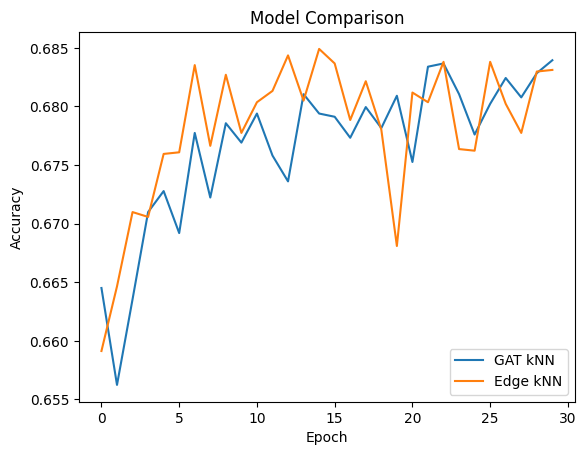

In [13]:
plt.plot(gat_test_knn_acc, label="GAT kNN")
plt.plot(edge_test_knn_acc, label="Edge kNN")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [14]:
from sklearn.metrics import roc_auc_score

def compute_auc(model, loader):
    model.eval()
    y_true = []
    y_scores = []

    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        probs = torch.softmax(out, dim=1)[:, 1]

        y_true.extend(data.y.cpu().numpy())
        y_scores.extend(probs.detach().cpu().numpy())

    return roc_auc_score(y_true, y_scores)

print("GAT AUC:", compute_auc(gat_knn, test_loader_knn))
print("EdgeConv AUC:", compute_auc(edge_knn, test_loader_knn))

GAT AUC: 0.7490589706169137
EdgeConv AUC: 0.7382614523028732


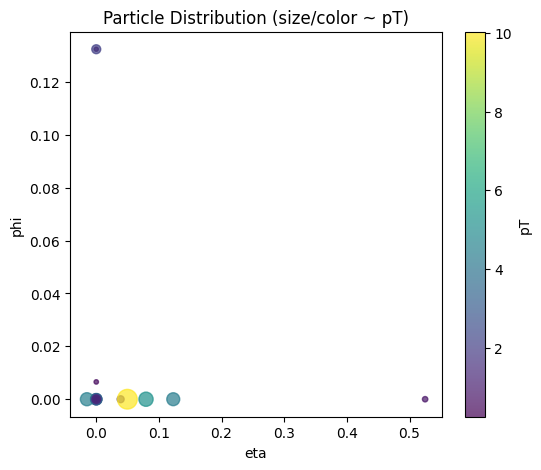

In [17]:
def plot_particles_pt(particles):
    eta = particles[:, 2]
    phi = particles[:, 3]
    pt  = particles[:, 0]

    plt.figure(figsize=(6,5))
    plt.scatter(
        eta,
        phi,
        s=pt * 20,          # size ~ pT
        c=pt,               # color ~ pT
        cmap="viridis",
        alpha=0.7
    )
    plt.colorbar(label="pT")
    plt.xlabel("eta")
    plt.ylabel("phi")
    plt.title("Particle Distribution (size/color ~ pT)")
    plt.show()

jet = df.iloc[0]["X_jets"]
particles = jet_to_particles(jet)

plot_particles_pt(particles)

## Results

We track model performance across epochs and compare accuracy between GAT and EdgeConv architectures.   
Best GAT KNN: 0.6839421088904204   
Best EdgeConv KNN: 0.6849069607167471

## Discussion

Both GAT and EdgeConv models achieve comparable performance, with test accuracy stabilizing around 0.68–0.685. EdgeConv consistently performs slightly better than GAT, indicating that explicitly modeling local geometric relationships between particles is beneficial for this task.

The training curves show that both models converge within 15–20 epochs, after which improvements are marginal. The small gap between training and test accuracy suggests that the models generalize reasonably well without significant overfitting.

The results highlight the effectiveness of graph-based representations for jet classification. By converting calorimeter images into particle-level graphs, the models can exploit spatial and relational structure that is difficult to capture using traditional CNN-based approaches.

However, the moderate accuracy also reflects the intrinsic difficulty of quark–gluon discrimination, where class boundaries are not sharply defined and detector noise introduces additional complexity.

Overall, this study demonstrates that Graph Neural Networks are a promising approach for particle physics tasks, with EdgeConv showing a slight advantage due to its ability to capture local geometric interactions more explicitly.